# **Mission 3 - Exploratory Data Analysis (EDA) with the Sales Dataset using Pandas and d Matplotlib/Seaborn**

### **Objective:**

The goal of this assignment is to help you apply your knowledge of Python for basic operations, Pandas for data manipulation, and Matplotlib/Seaborn for visualizations. You'll be working with a real-world dataset, and your tasks will include loading the data, performing EDA, and visualising the results.

###  **Dataset**

The dataset represents transaction data from a retail business, specifically sales data for products sold in various stores. It contains multiple tables that provide insights into sales, invoices, and products. Let’s break down the tables and what they represent:

#### Sales Table:

InvoiceNo: The unique identifier for each invoice (or transaction).

StockCode: A unique identifier for each product.

Quantity: The number of units sold in each transaction.

UnitPrice: The price per unit of the product.

InvoiceDate: The date when the transaction occurred.

#### Invoice Table:

InvoiceNo: The same unique identifier for each invoice, linking the sales data with the invoice details.

Country: The country where the sale was made.

#### Product Table:

StockCode: A unique identifier for each product.

Description: The name or description of the product.

Product_Category: The category the product belongs to (e.g., "Gift", "Sign", "Mug").



You will need to merge them and perform the following tasks step by step.


### Task 1: Load the Excel File
#### Objective: Import the data from the provided Excel file into Python using Pandas.

Instructions:

1. Upload the provided excel file into Fabric environment
2. Read each sheet of the excel file as a separate dataframe. 
3. Name the dataframe for sales as df_sales, the dataframe for invoice as df_invoice and the dataframe for product as df_product
4. Display the first few rows of each DataFrame to understand its structure.



In [ ]:
### Checking the sheet names

import pandas as pd

file_path = "./builtin/Online Sales Retailer.xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

['Sales', 'Invoice', 'Product', 'December_Sales']

In [ ]:
### Reading each sheet as a separate DataFrame

df_sales = pd.read_excel(file_path, sheet_name="Sales")

df_invoice = pd.read_excel(file_path, sheet_name="Invoice")

df_product = pd.read_excel(file_path, sheet_name="Product")

In [ ]:
### Displaying the first few rows of each DataFrame

display(df_sales.head())

display(df_invoice.head())

display(df_product.head())

### Task 2: Basic Python and Pandas Operations
#### Objective: Perform basic Python and Pandas operations to manipulate the data.

<mark>Instructions:</mark>

1. Create the Sales Column (Quantity * Unit Price) 

2. Check for missing values in the Sales DataFrame.

3. Replace any NaN values in the Sales and UnitPrice columns with 0.

4. Calculate basic descriptive statistics for the Quantity and UnitPrice columns (mean, median, mode, standard deviation).

In [ ]:
### Creating the Sales column

df_sales["Sales"] = df_sales["Quantity"] * df_sales["UnitPrice"]

In [ ]:
### Checking if the Sales calculation is correct

df_sales.head()

,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,Sales
0,536365,71053,6,3.39,2015-01-01,20.34
1,536365,22752,2,7.65,2015-01-01,15.30
2,536365,84406,8,2.75,2015-01-01,22.00
3,536366,84029,6,3.39,2015-01-01,20.34
4,536366,21730,6,4.25,2015-01-01,25.50


In [ ]:
### Checking for missing values

df_sales.isnull().sum()

### Results show that there are no missing values anywhre in df_sales


InvoiceNo      0
StockCode      0
Quantity       0
UnitPrice      0
InvoiceDate    0
Sales          0
dtype: int64

In [ ]:
### Replacing NaN values in Sales and UnitPrice with 0

df_sales["Sales"] = df_sales["Sales"].fillna(0)

df_sales["UnitPrice"] = df_sales["UnitPrice"].fillna(0)

### Checking if the replacing values with 0 worked

df_sales[["Sales", "UnitPrice"]].isnull().sum()


Sales        0
UnitPrice    0
dtype: int64

In [ ]:
### Calculating mean, median, mode and standard deviation for Quantity

print("Quantity Mean:", df_sales["Quantity"].mean())

print("Quantity Median:", df_sales["Quantity"].median())

print("Quantity Mode:", df_sales["Quantity"].mode()[0])

print("Quantity Standard Deviation:", df_sales["Quantity"].std())


Quantity Mean: 13.610961009642518
Quantity Median: 6.0
Quantity Mode: 1
Quantity Standard Deviation: 261.57756533207146


- The standard deviation here is too large, maybe there are outliers in the data.

In [ ]:
### Calculating mean, median, mode and standard deviation for UnitPrice

print("UnitPrice Mean:", df_sales["UnitPrice"].mean())

print("UnitPrice Median:", df_sales["UnitPrice"].median())

print("UnitPrice Mode:", df_sales["UnitPrice"].mode()[0])

print("UnitPrice Standard Deviation:", df_sales["UnitPrice"].std())


UnitPrice Mean: 3.0835027678710816
UnitPrice Median: 1.95
UnitPrice Mode: 1.25
UnitPrice Standard Deviation: 5.177652565375899


### Task 3: Merging DataFrames
#### Objective: Merge the Sales, Invoice, and Product tables based on common keys to perform a comprehensive analysis.

Instructions:

1. Merge the Sales DataFrame with the Invoice DataFrame on InvoiceNo.

2. Merge the result with the Product DataFrame on StockCode

In [ ]:
### Merging Sales dataframe and Invoice dataframe on InvoiceNo

### InvoiceNo links Sales to Invoive and StockCode links Sales to Product

### So I will use InvoiceNo to merge Sales and Invoice dataframes

df_merged = pd.merge(df_sales, df_invoice, on="InvoiceNo")

df_merged.head()

,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,Sales,Country
0,536365,71053,6,3.39,2015-01-01,20.34,United Kingdom
1,536365,22752,2,7.65,2015-01-01,15.30,United Kingdom
2,536365,84406,8,2.75,2015-01-01,22.00,United Kingdom
3,536366,84029,6,3.39,2015-01-01,20.34,United Kingdom
4,536366,21730,6,4.25,2015-01-01,25.50,United Kingdom


In [ ]:
### Merging the result with the Product dataFrame on StockCode

df_merged = pd.merge(df_merged, df_product, on="StockCode")

df_merged.head()

,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,Sales,Country,Description,Product_Category
0,536365,71053,6,3.39,2015-01-01,20.34,United Kingdom,PHOTO FRAME CORNICE,FRAME
1,536365,22752,2,7.65,2015-01-01,15.30,United Kingdom,TEA TIME TEAPOT IN GIFT BOX,GIFT
2,536365,84406,8,2.75,2015-01-01,22.00,United Kingdom,ZINC HEARTS PLANT POT HOLDER,HOLDER
3,536366,84029,6,3.39,2015-01-01,20.34,United Kingdom,FRENCH BLUE METAL DOOR SIGN 3,SIGN
4,536366,21730,6,4.25,2015-01-01,25.50,United Kingdom,CERAMIC CAKE DESIGN SPOTTED MUG,MUG


## Task 4: Exploratory Data Analysis (EDA)
### Objective: Conduct EDA by analysing the data, identifying patterns, trends, and outliers.

Instructions:

Use describe() to calculate summary statistics for numeric columns.

Perform basic filtering, such as filtering out sales with Quantity equal to 0.

Check for outliers in the Sales column by using a scatter plot.

In [ ]:
### Using describe() to calculate summary statistics for numeric columns

df_merged.describe()


,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,Sales
count,83277.000000,83277.000000,83277.000000,83277.000000,83277,83277.000000
mean,550244.000000,32948.774860,13.610961,3.083503,2016-12-31 00:00:00,23.121043
min,536365.000000,10002.000000,1.000000,0.000000,2015-01-01 00:00:00,0.000000
25%,543304.000000,21843.000000,2.000000,1.250000,2016-01-01 00:00:00,5.000000
50%,550244.000000,22470.000000,6.000000,1.950000,2016-12-31 00:00:00,12.500000
75%,557184.000000,22941.000000,12.000000,3.750000,2017-12-31 00:00:00,19.500000
max,564123.000000,90214.000000,74215.000000,295.000000,2018-12-31 00:00:00,77183.600000
std,8013.381169,22938.831323,261.577565,5.177653,NaN,278.041319


In [ ]:
### Performing basic filtering, such as filtering out sales with Quantity equal to 0.

df_filtered = df_merged[df_merged["Quantity"] != 0]

### Display the first few rows

df_filtered.head()

,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,Sales,Country,Description,Product_Category
0,536365,71053,6,3.39,2015-01-01,20.34,United Kingdom,PHOTO FRAME CORNICE,FRAME
1,536365,22752,2,7.65,2015-01-01,15.30,United Kingdom,TEA TIME TEAPOT IN GIFT BOX,GIFT
2,536365,84406,8,2.75,2015-01-01,22.00,United Kingdom,ZINC HEARTS PLANT POT HOLDER,HOLDER
3,536366,84029,6,3.39,2015-01-01,20.34,United Kingdom,FRENCH BLUE METAL DOOR SIGN 3,SIGN
4,536366,21730,6,4.25,2015-01-01,25.50,United Kingdom,CERAMIC CAKE DESIGN SPOTTED MUG,MUG


In [ ]:
### Checking how many rows were removed

print("Rows before filtering:", len(df_merged))

print("Rows after filtering:", len(df_filtered))


Rows before filtering: 83277
Rows after filtering: 83277


- The dataset contained 83,277 rows before filtering and 83,277 rows after filtering. 
- This indicates that there were no transactions with a Quantity value equal to 0, so no rows were removed.

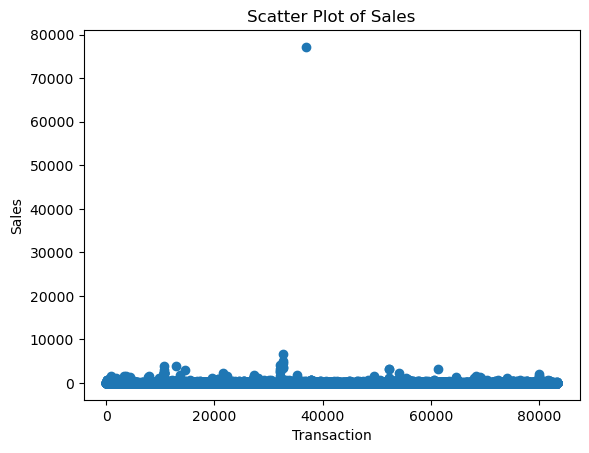

In [ ]:
### Checking for outliers in the Sales column by using a scatter plot.

import matplotlib.pyplot as plt

### Create a scatter plot to check for outliers in Sales

plt.scatter(df_filtered.index, df_filtered["Sales"])

plt.title("Scatter Plot of Sales")

plt.xlabel("Transaction")

plt.ylabel("Sales")

plt.show()


- The scatter plot shows that most Sales values are clustered at the lower end.
- There is a clear potential outlier with a Sales value of approximately 77,000.
- This value is considerably higher than the majority of transactions.

## Task 5: Data Visualisation – Scatter Plot, Histogram, and Line Chart
### Objective: Create scatter plots, histograms, and line charts to better understand the data.

Instructions:

Use a scatter plot to examine the relationship between Quantity and Sales.

Use a histogram to visualise the distribution of the Sales column.

Use a line chart to show the trend of Sales over time.

Write 1–2 sentences explaining the insights from each visualisation.

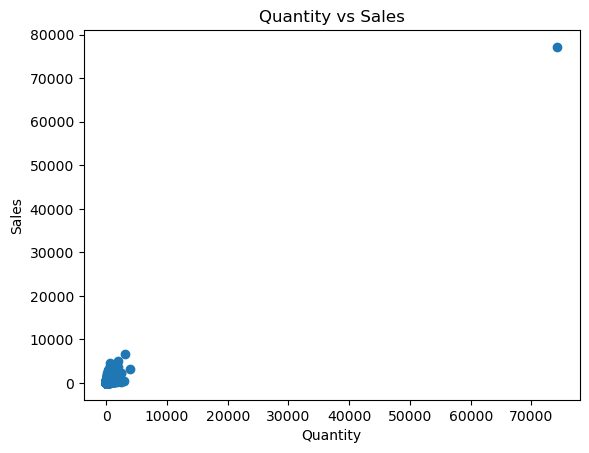

In [ ]:
### Using a scatter plot to examine the relationship between Quantity and Sales.

import matplotlib.pyplot as plt

plt.scatter(df_filtered["Quantity"], df_filtered["Sales"])

plt.title("Quantity vs Sales")

plt.xlabel("Quantity")

plt.ylabel("Sales")

plt.show()


- The scatter plot suggests that most of the slaes and quantity fall under 10000, The higher quantities are generally associated with higher Sales.
- However, one extreme transaction stands out from the majority of the data and may be an outlier.

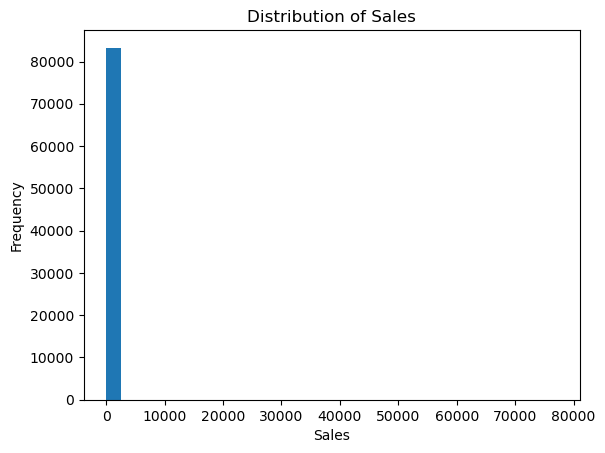

In [ ]:
### Using a histogram to visualise the distribution of the Sales column.

plt.hist(df_filtered["Sales"], bins=30)

plt.title("Distribution of Sales")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()



- The histogram shows that Sales values are heavily concentrated at the lower end of the distribution.
- A small number of very high Sales values, including the potential outlier, make the distribution strongly right-skewed.

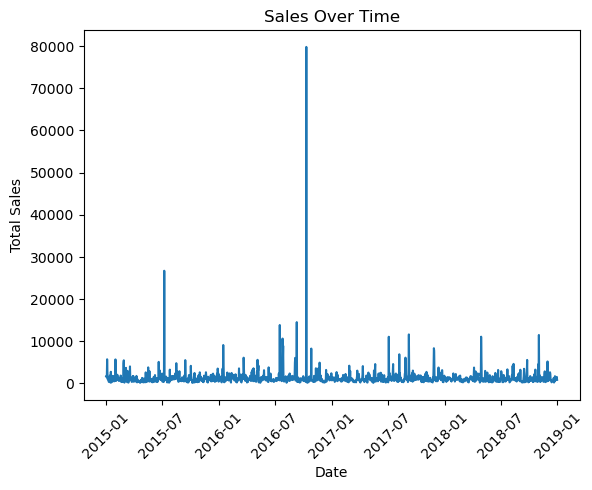

In [ ]:
### Calculate total Sales for each date

daily_sales = df_filtered.groupby("InvoiceDate")["Sales"].sum()

### Using a line chart to show the trend of Sales over time.

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Sales Over Time")

plt.xlabel("Date")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()



- The line chart shows that total Sales fluctuate over time, with several noticeable peaks.
- One exceptionally large spike stands out from the general sales pattern and is likely influenced by the high-value transaction identified earlier.

## Task 6: Correlation and Data Insights
### Objective: Identify the relationship between different numerical columns in the dataset.

Instructions:

Calculate the correlation between Quantity and Sales.

Visualise the correlation matrix using a heatmap.

Write 1–2 sentences explaining the insights from the visualisation.

In [ ]:
### Calculating the correlation between Quantity and Sales

correlation = df_filtered["Quantity"].corr(df_filtered["Sales"])

print("Correlation between Quantity and Sales:", correlation)

Correlation between Quantity and Sales: 0.9786092498011646


In [ ]:
### Creating the corelation matrix

correlation_matrix = df_filtered[["Quantity", "UnitPrice", "Sales"]].corr()

correlation_matrix

,Quantity,UnitPrice,Sales
Quantity,1.000000,-0.013917,0.978609
UnitPrice,-0.013917,1.000000,0.027060
Sales,0.978609,0.027060,1.000000


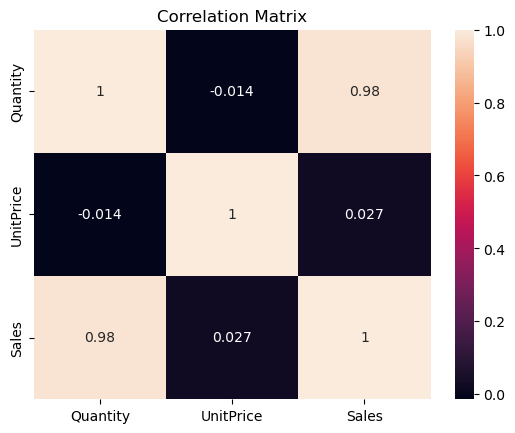

In [ ]:
### Vusualising the correlation using a heat map

import seaborn as sns

import matplotlib.pyplot as plt

sns.heatmap(correlation_matrix, annot=True)

plt.title("Correlation Matrix")

plt.show()



- The heatmap shows a very strong positive correlation (0.98) between Quantity and Sales,
- This indicate that higher quantities are generally associated with higher Sales values.
- UnitPrice has very little correlation with either Quantity or Sales.

## Task 7: Grouping and Aggregating
### Objective: Perform grouping and aggregation operations to summarise the data.

Instructions:

GroupBy operation: Group by Product_Category and calculate the total Sales per category.

Create a Pivot Table to show Sales by Country and Product_Category.

In [ ]:
### Using GroupBy operation for Group by Product_Category and calculating total Sales

sales_by_category = df_filtered.groupby("Product_Category")["Sales"].sum()

sales_by_category

Product_Category
APRON            3858.13
BACKPACK           97.30
BADGES           2415.15
BAG             45694.01
BALLOONS          297.12
                  ...   
WINDMILL          201.64
WOOD LETTERS     3126.40
WOODEN            311.75
WRAP            24542.26
WRITING          1448.80
Name: Sales, Length: 170, dtype: float64

In [ ]:
### Creating a Pivot Table to show Sales by Country and Product_Category.

pivot_sales = pd.pivot_table(

    df_filtered,
    values="Sales",
    index="Country",
    columns="Product_Category",
    aggfunc="sum"
)

pivot_sales

Product_Category,APRON,BACKPACK,BADGES,BAG,BALLOONS,BAND,BANGLE,BASKET,BEAD,BEAKER,...,TUBE,UMBRELLA,Uncategorized,WARMER,WATERING,WINDMILL,WOOD LETTERS,WOODEN,WRAP,WRITING
Country,,,,,,,,,,,,,,,,,,,,,
AUS,NaN,NaN,NaN,15.60,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,10.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Australia,NaN,NaN,NaN,188.56,10.08,NaN,NaN,NaN,23.80,38.40,...,14.85,NaN,488.31,NaN,142.50,NaN,NaN,NaN,29.50,25.5
Austria,NaN,NaN,NaN,58.18,NaN,NaN,NaN,NaN,NaN,111.90,...,NaN,NaN,111.16,NaN,NaN,NaN,NaN,NaN,15.60,NaN
Bahrain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,46.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Belgium,45.27,NaN,17.85,206.74,NaN,NaN,NaN,18.85,31.76,24.75,...,NaN,30.00,959.01,22.50,4.95,NaN,NaN,NaN,213.76,NaN
Brazil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Canada,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel Islands,5.04,NaN,NaN,80.75,5.95,NaN,NaN,76.50,NaN,NaN,...,NaN,15.00,165.47,NaN,NaN,NaN,NaN,NaN,14.24,NaN
Cyprus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,153.34,22.50,NaN,NaN,NaN,NaN,51.58,NaN


## Submission Guidelines:
Submit the Python notebook with all the tasks and visualisations.

Ensure that each task is clearly explained and that all steps are followed.

Include markdown explanations where necessary to explain your thought process.

Good work